In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import torch
print(torch.cuda.is_available())

# for RTX 5080
"""pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128"""

import numpy as np
import librosa
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

# --- 1. Configuration ---
DATA_DIR = r"E:\KOULU\IRMAS\IRMAS-TrainingData" 
TEST_DIR = r"E:\KOULU\IRMAS\IRMAS-TestingData\Part1Part2Part3"
BATCH_SIZE = 32
IMG_SHAPE = (128, 130, 1)
PRED_THRESHOLD = 0.20

instrument_list = ['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'sax', 'tru', 'vio', 'voi']
label_map = {inst: i for i, inst in enumerate(instrument_list)}
NUM_CLASSES = len(instrument_list)

instrument_map = {
    'cel': 'Celesta',         'cla': 'Clarinet',        'flu': 'Flute',
    'gac': 'Acoustic Guitar', 'gel': 'Electric Guitar', 'org': 'Organ',
    'pia': 'Piano',           'sax': 'Saxophone',       'tru': 'Trumpet',
    'vio': 'Violin',          'voi': 'Human Voice'
}

True


In [2]:
# --- 2. File Discovery ---
file_paths = []
labels = []

for root, dirs, files in os.walk(DATA_DIR):
    folder_name = os.path.basename(root)
    if folder_name in label_map:
        idx = label_map[folder_name]
        for file in files:
            if file.endswith(".wav"):
                file_paths.append(os.path.join(root, file))
                # Change: labels are float32 vectors of shape (11,), each position represents one instrument (0.0 or 1.0)
                label_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
                label_vec[idx] = 1.0
                labels.append(label_vec)

labels = np.array(labels, dtype=np.float32)  # Change: shape (N, 11) instead of (N,)
print(f"Found {len(file_paths)} training files")

# Split training data to train/val
# Change: stratify uses argmax because labels are now vectors
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42,
    stratify=np.argmax(labels, axis=1)
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

# Compute weights (Added in v4)
# Convert one-hot to integer labels for weight computation
train_labels_int = np.argmax(train_labels, axis=1)
classes = np.unique(train_labels_int)
weights = compute_class_weight('balanced', classes=classes, y=train_labels_int)
class_weight_dict = dict(enumerate(weights))

print("Class weights:", class_weight_dict)

Found 6705 training files
Train: 5364 | Val: 1341
Class weights: {0: np.float64(1.5730205278592375), 1: np.float64(1.207020702070207), 2: np.float64(1.3507932510702594), 3: np.float64(0.9561497326203209), 4: np.float64(0.8020334928229665), 5: np.float64(0.8931068931068931), 6: np.float64(0.8451236804789665), 7: np.float64(0.9733260751224823), 8: np.float64(1.0577795306645632), 9: np.float64(1.0509404388714734), 10: np.float64(0.7839812920198772)}


Custom SpecAugment layer to augment our data. Mimics real-world edge cases. The augmentation policy consists of warping the features, masking blocks of frequency channels, and masking blocks of time steps.

In [3]:
import torch.nn as nn

@keras.saving.register_keras_serializable()
class SimpleSpecAugment(nn.Module):
    """PyTorch-native SpecAugment for use with Keras+Torch backend."""
    
    def __init__(self, time_masks=3, freq_masks=3, time_mask_param=50, 
                 freq_mask_param=25, noise_std=0.01):
        super().__init__()
        self.time_masks = time_masks
        self.freq_masks = freq_masks
        self.time_mask_param = time_mask_param
        self.freq_mask_param = freq_mask_param
        self.noise_std = noise_std
        
    def forward(self, inputs, training=True):
        if not training:
            return inputs
            
        # inputs shape: (batch, height, width, channels)
        result = inputs.clone()
        batch_size, h, w, c = result.shape

        # Add Gaussian noise
        if self.noise_std > 0:
            noise = torch.randn_like(result) * self.noise_std
            result = result + noise
        
        # Frequency masking (along height dimension)
        for _ in range(self.freq_masks):
            # Random mask size and position for each batch item
            mask_size = torch.randint(0, self.freq_mask_param, (1,)).item()
            if mask_size >= h:
                continue
                
            mask_start = torch.randint(0, h - mask_size, (1,)).item()
            
            # Apply mask
            result[:, mask_start:mask_start + mask_size, :, :] = 0
        
        # Time masking (along width dimension)
        for _ in range(self.time_masks):
            mask_size = torch.randint(0, self.time_mask_param, (1,)).item()
            if mask_size >= w:
                continue
                
            mask_start = torch.randint(0, w - mask_size, (1,)).item()
            
            # Apply mask
            result[:, :, mask_start:mask_start + mask_size, :] = 0
            
        return result
    
    def get_config(self):
        """Returns the configuration of the layer for serialization."""
        return {
            'time_masks': self.time_masks,
            'freq_masks': self.freq_masks,
            'time_mask_param': self.time_mask_param,
            'freq_mask_param': self.freq_mask_param,
            'noise_std': self.noise_std,
        }

Wrapper to enable sequential Keras model use with SpecAug.

In [ ]:
@keras.saving.register_keras_serializable()
class SpecAugmentWrapper(tf.keras.layers.Layer):
    """Wrapper that applies SpecAugment using PyTorch operations."""
    
    def __init__(self, time_masks=2, freq_masks=2, time_mask_param=40, freq_mask_param=20, noise_std=0.01, **kwargs):
        super().__init__(**kwargs)
        self.time_masks = time_masks
        self.freq_masks = freq_masks
        self.time_mask_param = time_mask_param
        self.freq_mask_param = freq_mask_param
        self.noise_std = noise_std
        # Create the PyTorch module
        self.specaugment = SimpleSpecAugment(
            time_masks, freq_masks, time_mask_param, freq_mask_param, noise_std
        )
    
    def call(self, inputs, training=None):
        if training:
            # Apply SpecAugment
            return self.specaugment(inputs, training=True)
        return inputs
    
    def get_config(self):
        """Returns the configuration of the layer for serialization."""
        config = super().get_config()
        config.update({
            'time_masks': self.time_masks,
            'freq_masks': self.freq_masks,
            'time_mask_param': self.time_mask_param,
            'freq_mask_param': self.freq_mask_param,
            'noise_std': self.noise_std,
        })
        return config
    
    @classmethod
    def from_config(cls, config):
        """Creates the layer from its configuration."""
        return cls(**config)

In [5]:
# Converts raw .wav files into normalized Mel-spectrogram images for the CNN to "see"
def process_audio(file_path, label):
    def _parse_audio(fp):
        # Convert the TensorFlow tensor back into a standard Python string (file path)
        fp = fp.numpy().decode('utf-8')
        
        # Load audio file: 22050 samples per second, restricted to exactly 3.0 seconds
        audio, _ = librosa.load(fp, sr=22050, duration=3.0)
        
        # If audio is shorter than 3s (66,150 samples), add zeros to the end
        if len(audio) < 66150:
            audio = np.pad(audio, (0, 66150 - len(audio)))
        
        # Convert raw sound waves into a Mel-spectrogram (frequency over time)
        # n_mels=128 creates 128 vertical "frequency bins"
        spec = librosa.feature.melspectrogram(y=audio, sr=22050, n_mels=128)
        
        # Convert amplitude units to Decibels (log scale) so details aren't lost
        spec_db = librosa.power_to_db(spec, ref=np.max)
        
        # Normalize: shift -80..0 range to 0..1 for faster training (v2)
        spec_db = (spec_db + 80.0) / 80.0
        spec_db = np.clip(spec_db, 0, 1)
        
        # Add a gray channel dimension (128, 130) -> (128, 130, 1) to mimic a grayscale image
        return spec_db[..., np.newaxis].astype(np.float32)

    # Wrap the Python function so TensorFlow can run it as part of the "Graph"
    [image,] = tf.py_function(_parse_audio, [file_path], [tf.float32])
    image.set_shape(IMG_SHAPE)
    
    return image, label

# Builds an optimized, shuffled, and batched data pipeline to feed the GPU efficiently
def make_dataset(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(len(paths))
    ds = ds.map(process_audio, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels)
val_ds   = make_dataset(val_paths,   val_labels)

In [6]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=IMG_SHAPE),

    SpecAugmentWrapper(time_masks=2, freq_masks=2, time_mask_param=20, freq_mask_param=10, noise_std=0.005),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.GlobalMaxPooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    # Change: sigmoid instead of softmax
    tf.keras.layers.Dense(NUM_CLASSES, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    # Change: binary_crossentropy
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        # Change: Add AUC (Area Under the Curve) measures how well the model ranks instruments (regardless of threshold)
        # 0.5 = random guessing, 1.0 = perfect
        tf.keras.metrics.AUC(multi_label=True, name='auc')
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spec_augment_wrapper            │ (None, 128, 130, 1)    │             0 │
│ (SpecAugmentWrapper)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,939 (113.04 KB)

 Trainable params: 28,747 (112.29 KB)

 Non-trainable params: 192 (768.00 B)

In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Reduce learning rate if plateau (Added in v4)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.4, patience=5, min_lr=1e-6
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    epochs=300,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/300
168/168 ━━━━━━━━━━━━━━━━━━━━ 33s 191ms/step - accuracy: 0.0904 - auc: 0.4971 - loss: 0.8158 - val_accuracy: 0.0597 - val_auc: 0.5134 - val_loss: 0.6713 - learning_rate: 1.0000e-04
Epoch 2/300
168/168 ━━━━━━━━━━━━━━━━━━━━ 32s 188ms/step - accuracy: 0.0902 - auc: 0.4995 - loss: 0.4035 - val_accuracy: 0.1126 - val_auc: 0.4812 - val_loss: 0.6243 - learning_rate: 1.0000e-04
Epoch 3/300
168/168 ━━━━━━━━━━━━━━━━━━━━ 32s 190ms/step - accuracy: 0.0859 - auc: 0.5028 - loss: 0.3672 - val_accuracy: 0.1163 - val_auc: 0.4901 - val_loss: 0.5712 - learning_rate: 1.0000e-04
Epoch 4/300
168/168 ━━━━━━━━━━━━━━━━━━━━ 32s 189ms/step - accuracy: 0.0865 - auc: 0.5059 - loss: 0.3544 - val_accuracy: 0.1163 - val_auc: 0.5106 - val_loss: 0.5207 - learning_rate: 1.0000e-04
Epoch 5/300
168/168 ━━━━━━━━━━━━━━━━━━━━ 32s 189ms/step - accuracy: 0.0969 - auc: 0.5057 - loss: 0.3484 - val_accuracy: 0.1141 - val_auc: 0.5184 - val_loss: 0.4878 - learning_rate: 1.0000e-04
Epoch 6/300
168/168 ━━━━━━━━━━━━━━━━━━━━

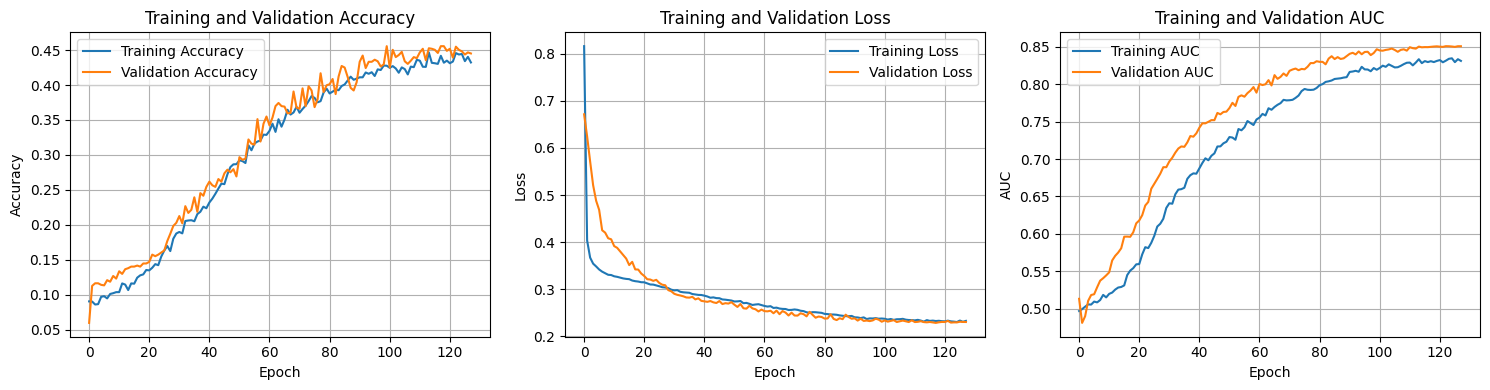

Best epoch: 118
Validation Accuracy: 0.4556
Validation Loss:     0.2287
Validation AUC:      0.8498
------------------------------
Training Accuracy:   0.4418
Training Loss:       0.2326


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))  # Change: fit new AUC plot

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch');  plt.ylabel('Accuracy');  plt.legend();  plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch');  plt.ylabel('Loss');  plt.legend();  plt.grid(True)

# Change: added AUC plot = tracks how well the model ranks instruments overall (unaffected by the choice of threshold)
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'],     label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Training and Validation AUC')
plt.xlabel('Epoch');  plt.ylabel('AUC');  plt.legend();  plt.grid(True)

plt.tight_layout()
plt.show()

best_epoch = np.argmin(history.history['val_loss'])
print(f"Best epoch: {best_epoch + 1}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")
print(f"Validation Loss:     {history.history['val_loss'][best_epoch]:.4f}")
print(f"Validation AUC:      {history.history['val_auc'][best_epoch]:.4f}")  # Change: added AUC
print("-" * 30)
print(f"Training Accuracy:   {history.history['accuracy'][best_epoch]:.4f}")
print(f"Training Loss:       {history.history['loss'][best_epoch]:.4f}")

In [9]:
from sklearn.metrics import f1_score

# (Added in v4)
def find_optimal_thresholds(y_true, y_pred_probs, val_data):
    """Find best threshold per class using validation set"""
    optimal_thresholds = []
    
    for i in range(NUM_CLASSES):
        best_f1 = 0
        best_thresh = 0.2  # default
        
        for thresh in np.arange(0.1, 0.6, 0.05):
            y_pred_binary = (y_pred_probs[:, i] > thresh).astype(int)
            f1 = f1_score(y_true[:, i], y_pred_binary)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
                
        optimal_thresholds.append(best_thresh)
        print(f"{instrument_list[i]}: threshold={best_thresh:.3f}, F1={best_f1:.3f}")
    
    return optimal_thresholds

In [10]:
## THRESHOLD IS THE CONFIDENCE BAR WHICH DECIDES IF THERE IS AN X INSTRUMENT IN THE SAMPLE.
## WE HAVE 11 INSTRUMENTS SO RANDOM GUESSING WOULD BE AROUND 0.09.
## SO IF WE HAVE THRESHOLD OF 0.20 IT NEEDS TO HAVE ATLEAST 0.20 PROBABILITY TO BE FLAGGED
## THAT THE INSTRUMENT IS IN THE SAMPLE.

# Change: returns a probability vector (11,) instead of a single float for one instrument -> all instruments are evaluated in one pass per file
def predict_on_test_file(file_path, model):
    audio, sr = librosa.load(file_path, sr=22050)  # sample rate, 22,050 * 3 = 66,150 samples per chunk
    chunk_size = 66150  # 3 seconds
    chunk_probs = []

    for i in range(0, len(audio) - chunk_size, chunk_size):
        chunk = audio[i : i + chunk_size]
        spec    = librosa.feature.melspectrogram(y=chunk, sr=sr, n_mels=128)
        spec_db = librosa.power_to_db(spec, ref=np.max)  # v2
        spec_db = (spec_db + 80.0) / 80.0               # v2
        spec_db = np.clip(spec_db, 0, 1)                 # v2
        inp  = spec_db[np.newaxis, ..., np.newaxis]
        pred = model.predict(inp, verbose=0)
        chunk_probs.append(pred[0])  # CHANGED: shape (11,) instead of a single float

    # Return the highest confidence found across all 3s windows per instrument
    # If the instrument appears once, the whole file is flagged as a match (depending on the threshold)
    # Change: np.max over axis=0 to get per-instrument max across chunks
    return np.max(chunk_probs, axis=0) if chunk_probs else np.zeros(NUM_CLASSES)

def predict_with_dynamic_threshold(file_path, model, thresholds):
    probs = predict_on_test_file(file_path, model)
    return (probs > thresholds).astype(int)

test_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith('.wav')])

# Change: y_true and y_pred_probs are now 2D arrays (num_files, 11) instead of 1D
y_true       = []
y_pred_probs = []
y_pred_binary = []

# Acquire optimal thresholds for instrument recog from validation set (Added in v4)
val_pred_probs = model.predict(val_ds)
optimal_thresholds = find_optimal_thresholds(val_labels, val_pred_probs, val_ds)

for f in test_files:
    file_path = os.path.join(TEST_DIR, f)
    txt_path  = os.path.splitext(file_path)[0] + '.txt'

    # Change: label is now a vector — all instruments mentioned in the .txt are flagged
    label_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    if os.path.exists(txt_path):
        with open(txt_path, 'r') as t:
            labels_in_file = [item.strip() for item in t.read().split()]
            for code in labels_in_file:
                if code in label_map:
                    label_vec[label_map[code]] = 1.0

    y_true.append(label_vec)
    y_pred_binary.append(predict_with_dynamic_threshold(file_path, model, thresholds=optimal_thresholds))

    # raw probabilities for AUC score
    probs = predict_on_test_file(file_path, model)
    y_pred_probs.append(probs)

y_true        = np.array(y_true)
y_pred_binary = np.array(y_pred_binary)

print(f"Evaluated {len(test_files)} test files")

42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 169ms/step
cel: threshold=0.100, F1=0.109
cla: threshold=0.200, F1=0.151
flu: threshold=0.100, F1=0.105
gac: threshold=0.100, F1=0.160
gel: threshold=0.100, F1=0.160
org: threshold=0.100, F1=0.130
pia: threshold=0.100, F1=0.149
sax: threshold=0.100, F1=0.118
tru: threshold=0.100, F1=0.109
vio: threshold=0.100, F1=0.091
voi: threshold=0.100, F1=0.145
Evaluated 2874 test files


In [11]:
# RECALL    = "Of all the X instruments in the test set, how many did the model actually find?"
# PRECISION = "When the model says it's a X instrument, how often is it actually a X instrument?"
# F1 SCORE  = harmonic mean of precision and recall "The balance of the two"

# Change: one report to cover all 11 instruments
print(f"Multilabel Classification Report (thresholds={optimal_thresholds}):\n")
print(classification_report(
    y_true,
    y_pred_binary,
    target_names=[instrument_map[k] for k in instrument_list]
))

Multilabel Classification Report (thresholds=[np.float64(0.1), np.float64(0.20000000000000004), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1)]):

                 precision    recall  f1-score   support

        Celesta       0.12      0.71      0.20       111
       Clarinet       0.06      0.47      0.11        62
          Flute       0.09      0.84      0.16       163
Acoustic Guitar       0.29      0.64      0.40       535
Electric Guitar       0.51      0.83      0.63       942
          Organ       0.22      0.58      0.32       361
          Piano       0.57      0.45      0.50       995
      Saxophone       0.23      0.84      0.37       326
        Trumpet       0.10      0.64      0.17       167
         Violin       0.21      0.82      0.34       211
    Human Voice       0.59      0.87      0.70      1044

      micro avg       0.30      0.71      0.42      4917
     

e:\KOULU\Neural-Networks-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_true, y_pred_probs, average='macro')
print(f"Test AUC: {auc_score:.4f}")

Test AUC: 0.7664


In [13]:
model.save("irmas_instrument_classifier_v3_multilabel_data_aug.keras")
print("Model saved.")

Model saved.
